# 03c: Statistical Model Comparison

**Purpose:** Rigorous statistical comparison of all baseline models

**Dataset:** COMPAS predictions from all baseline models

**Date:** 2025-11-08

---

## Overview

### Purpose
Statistically compare baseline models using:
- **DeLong test**: Compare AUROC values
- **McNemar's test**: Compare prediction agreement
- **Permutation tests**: Compare arbitrary metrics
- **Multiple comparison corrections**: Bonferroni, Holm, Benjamini-Hochberg
- **Effect sizes**: Practical significance beyond p-values

### Models Compared
1. Logistic Regression (baseline)
2. XGBoost
3. LightGBM
4. CatBoost

### Statistical Framework
- **Null hypothesis**: No difference between models
- **Significance level**: α = 0.05 (with corrections)
- **Effect size threshold**: Cohen's d ≥ 0.2 (small effect)

### Outputs
- Statistical test results → `results/metrics/model_comparison_stats.json`
- Comparison table → `results/tables/baseline_model_comparison.csv`
- Visualizations → `results/figures/model_performance/`

### Runtime: 2-5 minutes

---

In [1]:
# Setup
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score
)
from scipy import stats

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "src"))

# Our statistical utilities
from statistics_utils.hypothesis_tests import mcnemar_test, delong_test, permutation_test
from statistics_utils.effect_sizes import cohens_d, number_needed_to_evaluate
from statistics_utils.multiple_comparisons import holm_correction, benjamini_hochberg

# Directories
PROCESSED_DIR = project_root / "data" / "processed"
PREDICTIONS_DIR = project_root / "results" / "predictions"
METRICS_DIR = project_root / "results" / "metrics"
TABLES_DIR = project_root / "results" / "tables"
FIGURES_DIR = project_root / "results" / "figures" / "model_performance"

for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
ALPHA = 0.05

print("✓ Setup complete")

✓ Setup complete


## 1. Load All Model Predictions

In [2]:
# Load ground truth
y_test = pd.read_parquet(PROCESSED_DIR / "compas_y_test.parquet")['two_year_recid']

# Load all model predictions
models = ['logistic_regression', 'xgboost', 'lightgbm', 'catboost']
predictions = {}
metrics_summary = []

for model in models:
    # Load predictions
    pred_df = pd.read_parquet(PREDICTIONS_DIR / f"{model}_predictions.parquet")
    test_df = pred_df[pred_df['split'] == 'test'].reset_index(drop=True)
    
    predictions[model] = {
        'y_proba': test_df['y_proba'].values,
        'y_pred': test_df['y_pred'].values
    }
    
    # Load metrics
    with open(METRICS_DIR / f"{model}_metrics.json", 'r') as f:
        metrics = json.load(f)
    
    metrics_summary.append({
        'model': model.replace('_', ' ').title(),
        'auroc': metrics['test']['auroc'],
        'auprc': metrics['test']['auprc'],
        'accuracy': metrics['test']['accuracy'],
        'f1': metrics['test']['f1'],
        'brier_score': metrics['test']['brier_score']
    })

# Create summary DataFrame
metrics_df = pd.DataFrame(metrics_summary)

print("Loaded predictions from all models:")
print(metrics_df.to_string(index=False))
print(f"\nTest set size: {len(y_test)}")

Loaded predictions from all models:
              model    auroc    auprc  accuracy       f1  brier_score
Logistic Regression 0.713760 0.704687  0.673704 0.660679     0.215779
            Xgboost 0.712446 0.706674  0.650672 0.616034     0.215667
           Lightgbm 0.711785 0.708229  0.654511 0.627329     0.215632
           Catboost 0.709894 0.696969  0.655470 0.630278     0.216829

Test set size: 1042


## 2. Pairwise AUROC Comparison (DeLong Test)

DeLong's test compares two correlated ROC curves (same test set).

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from math import isfinite
try:
    from scipy.stats import norm
except Exception:
    norm = None  # we will handle lack of SciPy gracefully

# =========================
# Multiple comparison helpers
# =========================
def holm_correction(p_values, alpha=0.05):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]

    # Holm step-down adjusted p-values
    adj = np.empty_like(ranked)
    for i, pv in enumerate(ranked):
        adj[i] = (m - i) * pv
    # ensure monotonic non-decreasing when mapped back to original order after max cum
    adj = np.maximum.accumulate(np.minimum(adj, 1.0))
    adjusted = np.empty_like(adj)
    adjusted[order] = adj

    # Rejections (Holm step-down): find first non-reject and reject all before
    reject = np.zeros(m, dtype=bool)
    for i, pv in enumerate(ranked):
        if pv > alpha / (m - i):
            # stop; no more rejections
            break
        reject[i] = True
    rejected = np.zeros(m, dtype=bool)
    rejected[order] = reject
    return {"adjusted_p_values": adjusted, "rejected": rejected}

def benjamini_hochberg(p_values, alpha=0.05):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    # BH adjusted p-values
    adj = np.empty_like(ranked, dtype=float)
    for i, pv in enumerate(ranked, start=1):
        adj[i-1] = pv * m / i
    # make monotone non-increasing when reversed (then flip back) and clip to [0,1]
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    adjusted = np.empty_like(adj)
    adjusted[order] = adj
    # BH rejection rule
    thresh = alpha * (np.arange(1, m+1) / m)
    k = np.max(np.where(ranked <= thresh)[0], initial=-1)
    reject_ranked = np.zeros(m, dtype=bool)
    if k >= 0:
        reject_ranked[:k+1] = True
    rejected = np.zeros(m, dtype=bool)
    rejected[order] = reject_ranked
    return {"adjusted_p_values": adjusted, "rejected": rejected}

# =========================
# Utilities
# =========================
def ensure_1d_score(scores, y_true=None):
    """
    Make sure we pass a 1D score/probability for the *positive* class to roc_auc_score.
    Accepts 1D arrays, Pandas Series, or 2D arrays with shape (n_samples, 2) and takes column 1.
    """
    arr = np.asarray(scores)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2 and arr.shape[1] == 2:
        return arr[:, 1]
    # If user supplied probabilities for multiple classes, try to infer positive class as max label in y_true
    if arr.ndim == 2 and y_true is not None:
        # assume positive class is the max label in y_true (works for binary 0/1 labels)
        pos_idx = int(np.argmax(np.unique(y_true)))
        if 0 <= pos_idx < arr.shape[1]:
            return arr[:, pos_idx]
    raise ValueError("y_proba must be 1D scores or (n_samples, 2) with positive-class probs in column 1.")

def parse_delong_result(res, auc1, auc2):
    """
    Normalize various delong_test return formats to a dict with keys:
    z_statistic, p_value, auroc1, auroc2
    """
    z_statistic = np.nan
    p_value = np.nan
    # Case 1: dictionary-like result
    if isinstance(res, dict):
        # Try a few common key names
        p_value = res.get("p_value", res.get("p", res.get("pval", res.get("pvalue", np.nan))))
        z_statistic = res.get("z_statistic", res.get("z", res.get("zvalue", np.nan)))
        # Some implementations might include aucs under different names; prefer our computed ones
        return {
            "z_statistic": z_statistic,
            "p_value": p_value,
            "auroc1": auc1,
            "auroc2": auc2
        }

    # Case 2: tuple/list result
    if isinstance(res, (tuple, list)):
        if len(res) == 2:
            z_statistic, p_value = res
        elif len(res) >= 4:
            # Sometimes: (auc1, auc2, z, p)
            maybe_auc1, maybe_auc2, maybe_z, maybe_p = res[:4]
            # Keep our own aucs but use z and p when present
            if isfinite(maybe_z):
                z_statistic = maybe_z
            if isfinite(maybe_p):
                p_value = maybe_p
        elif len(res) == 1:
            p_value = float(res[0])
        return {
            "z_statistic": z_statistic,
            "p_value": p_value,
            "auroc1": auc1,
            "auroc2": auc2
        }

    # Case 3: scalar p-value only
    if np.isscalar(res):
        p_value = float(res)
        return {
            "z_statistic": z_statistic,
            "p_value": p_value,
            "auroc1": auc1,
            "auroc2": auc2
        }

    # Fallback
    return {
        "z_statistic": z_statistic,
        "p_value": p_value,
        "auroc1": auc1,
        "auroc2": auc2
    }

def z_from_p_two_sided(p, diff_sign):
    """
    Reconstruct |z| from a two-sided p-value and apply the sign of AUC difference.
    Requires SciPy. If unavailable, returns NaN.
    """
    if norm is None or not np.isfinite(p) or p <= 0 or p > 1:
        return np.nan
    z_abs = norm.isf(p / 2.0)  # two-sided
    return float(np.sign(diff_sign) * z_abs)

# =========================
# Main pairwise DeLong comparison
# =========================
ALPHA = 0.05 if "ALPHA" not in globals() else ALPHA  # use existing ALPHA if defined

delong_results = []

for i, model1 in enumerate(models):
    for model2 in models[i+1:]:
        y1 = ensure_1d_score(predictions[model1]["y_proba"], y_true=y_test)
        y2 = ensure_1d_score(predictions[model2]["y_proba"], y_true=y_test)

        # Compute AUROCs explicitly (most delong_test functions do NOT return them)
        auc1 = roc_auc_score(y_test, y1)
        auc2 = roc_auc_score(y_test, y2)

        # Run user's DeLong test
        res_raw = delong_test(y_test, y1, y2)

        # Normalize whatever delong_test returned
        parsed = parse_delong_result(res_raw, auc1, auc2)

        # If z is missing but p is present, reconstruct z (signed by observed difference)
        if (not np.isfinite(parsed["z_statistic"])) and np.isfinite(parsed["p_value"]):
            parsed["z_statistic"] = z_from_p_two_sided(parsed["p_value"], auc1 - auc2)

        delong_results.append({
            "model1": model1.replace("_", " ").title(),
            "model2": model2.replace("_", " ").title(),
            "auroc1": parsed["auroc1"],
            "auroc2": parsed["auroc2"],
            "difference": parsed["auroc1"] - parsed["auroc2"],
            "z_statistic": parsed["z_statistic"],
            "p_value": parsed["p_value"]
        })

delong_df = pd.DataFrame(delong_results)

print("DeLong Test Results (Pairwise AUROC Comparisons):")
print("="*80)
print(delong_df.to_string(index=False))

# Multiple-comparison corrections
p_values = delong_df["p_value"].values
holm_result = holm_correction(p_values, alpha=ALPHA)
bh_result = benjamini_hochberg(p_values, alpha=ALPHA)

delong_df["p_holm"] = holm_result["adjusted_p_values"]
delong_df["sig_holm"] = holm_result["rejected"]
delong_df["p_bh"] = bh_result["adjusted_p_values"]
delong_df["sig_bh"] = bh_result["rejected"]

print("\nWith Multiple Comparison Corrections:")
print(delong_df[["model1", "model2", "difference", "p_value", "p_holm", "sig_holm"]].to_string(index=False))


DeLong Test Results (Pairwise AUROC Comparisons):
             model1   model2   auroc1   auroc2  difference  z_statistic  p_value
Logistic Regression  Xgboost 0.713760 0.712446    0.001314     0.291874 0.770383
Logistic Regression Lightgbm 0.713760 0.711785    0.001976     0.472495 0.636573
Logistic Regression Catboost 0.713760 0.709894    0.003867     0.994396 0.320030
            Xgboost Lightgbm 0.712446 0.711785    0.000662     0.397613 0.690916
            Xgboost Catboost 0.712446 0.709894    0.002553     0.753226 0.451314
           Lightgbm Catboost 0.711785 0.709894    0.001891     0.532554 0.594342

With Multiple Comparison Corrections:
             model1   model2  difference  p_value  p_holm  sig_holm
Logistic Regression  Xgboost    0.001314 0.770383     1.0     False
Logistic Regression Lightgbm    0.001976 0.636573     1.0     False
Logistic Regression Catboost    0.003867 0.320030     1.0     False
            Xgboost Lightgbm    0.000662 0.690916     1.0     False
    

## 3. Pairwise Prediction Comparison (McNemar's Test)

McNemar's test compares binary predictions (correct/incorrect).

In [6]:
import numpy as np
import pandas as pd

# Optional SciPy support for p-values (exact and chi-square). Falls back gracefully if missing.
try:
    from scipy.stats import chi2, binomtest
except Exception:
    chi2 = None
    binomtest = None

# Use your existing ALPHA if present
ALPHA = 0.05 if "ALPHA" not in globals() else ALPHA

# If your p-adjust helpers are not already defined, define minimal versions
try:
    holm_correction
except NameError:
    def holm_correction(p_values, alpha=0.05):
        p = np.asarray(p_values, dtype=float)
        m = len(p)
        order = np.argsort(p)
        ranked = p[order]
        adj = np.minimum.accumulate((ranked * (m - np.arange(m)))[::-1])[::-1]
        adj = np.clip(adj, 0, 1)
        adjusted = np.empty_like(adj); adjusted[order] = adj
        # Step-down reject rule
        reject_ranked = np.zeros(m, dtype=bool)
        for i, pv in enumerate(ranked):
            if pv <= alpha / (m - i): reject_ranked[i] = True
            else: break
        rejected = np.zeros(m, dtype=bool); rejected[order] = reject_ranked
        return {"adjusted_p_values": adjusted, "rejected": rejected}

try:
    benjamini_hochberg
except NameError:
    def benjamini_hochberg(p_values, alpha=0.05):
        p = np.asarray(p_values, dtype=float)
        m = len(p)
        order = np.argsort(p)
        ranked = p[order]
        adj = ranked * m / (np.arange(1, m+1))
        adj = np.minimum.accumulate(adj[::-1])[::-1]
        adj = np.clip(adj, 0, 1)
        adjusted = np.empty_like(adj); adjusted[order] = adj
        thresh = alpha * (np.arange(1, m+1) / m)
        k = np.max(np.where(ranked <= thresh)[0], initial=-1)
        reject_ranked = np.zeros(m, dtype=bool)
        if k >= 0: reject_ranked[:k+1] = True
        rejected = np.zeros(m, dtype=bool); rejected[order] = reject_ranked
        return {"adjusted_p_values": adjusted, "rejected": rejected}

def _mcnemar_from_preds(y_true, y_pred1, y_pred2):
    """
    Build the paired correctness table and compute McNemar statistics.
    Returns a dict with the keys your downstream code expects.
    """
    y_true = np.asarray(y_true).ravel()
    p1 = np.asarray(y_pred1).ravel()
    p2 = np.asarray(y_pred2).ravel()
    if y_true.shape[0] != p1.shape[0] or y_true.shape[0] != p2.shape[0]:
        raise ValueError("y_true, y_pred1, and y_pred2 must have the same length.")

    correct1 = (p1 == y_true)
    correct2 = (p2 == y_true)

    both_correct  = int(np.sum(correct1 &  correct2))
    only_1_correct = int(np.sum(correct1 & ~correct2))   # b
    only_2_correct = int(np.sum(~correct1 &  correct2))  # c
    both_wrong    = int(np.sum(~correct1 & ~correct2))

    acc1 = float(np.mean(correct1))
    acc2 = float(np.mean(correct2))

    b = only_1_correct
    c = only_2_correct
    n_discordant = b + c

    # Continuity-corrected chi-square (Edwards 1948)
    statistic = np.nan
    p_chi2 = np.nan
    if n_discordant > 0:
        statistic = ((abs(b - c) - 1) ** 2) / n_discordant
        if chi2 is not None:
            p_chi2 = float(chi2.sf(statistic, 1))

    # Exact binomial two-sided p-value for small b+c
    p_exact = np.nan
    if n_discordant > 0 and binomtest is not None:
        p_exact = float(binomtest(min(b, c), n_discordant, 0.5, alternative="two-sided").pvalue)

    # Prefer exact when available; otherwise fall back to chi-square
    p_value = p_exact if np.isfinite(p_exact) else p_chi2

    return {
        "accuracy1": acc1,
        "accuracy2": acc2,
        # Shape chosen so that [0][0],[1][0],[0][1],[1][1] match your downstream indexing
        "contingency_table": [[both_correct, only_2_correct],
                              [only_1_correct, both_wrong]],
        "statistic": statistic,
        "p_value": p_value,
        "p_value_exact": p_exact,
        "p_value_chi2": p_chi2,
        "b": b,
        "c": c,
        "n_discordant": n_discordant
    }

# =========================
# All pairwise comparisons
# =========================
mcnemar_results = []

for i, model1 in enumerate(models):
    for model2 in models[i+1:]:
        # Compute McNemar summary directly from predictions
        result = _mcnemar_from_preds(
            y_test,
            predictions[model1]["y_pred"],
            predictions[model2]["y_pred"]
        )

        mcnemar_results.append({
            "model1": model1.replace("_", " ").title(),
            "model2": model2.replace("_", " ").title(),
            "accuracy1": result["accuracy1"],
            "accuracy2": result["accuracy2"],
            "both_correct": result["contingency_table"][0][0],
            "only_1_correct": result["contingency_table"][1][0],  # b
            "only_2_correct": result["contingency_table"][0][1],  # c
            "both_wrong": result["contingency_table"][1][1],
            "statistic": result["statistic"],
            "p_value": result["p_value"],
            "p_exact": result["p_value_exact"],
            "p_chi2": result["p_value_chi2"],
            "discordant_b_plus_c": result["n_discordant"]
        })

mcnemar_df = pd.DataFrame(mcnemar_results)

print("McNemar's Test Results (Pairwise Prediction Comparisons):")
print("="*80)
print(mcnemar_df.to_string(index=False))

# Multiple-comparison corrections
p_values_mc = mcnemar_df["p_value"].values
holm_mc = holm_correction(p_values_mc, alpha=ALPHA)
bh_mc = benjamini_hochberg(p_values_mc, alpha=ALPHA)

mcnemar_df["p_holm"] = holm_mc["adjusted_p_values"]
mcnemar_df["sig_holm"] = holm_mc["rejected"]
mcnemar_df["p_bh"] = bh_mc["adjusted_p_values"]
mcnemar_df["sig_bh"] = bh_mc["rejected"]

print("\nWith Multiple Comparison Corrections:")
print(mcnemar_df[["model1", "model2", "p_value", "p_holm", "sig_holm"]].to_string(index=False))


McNemar's Test Results (Pairwise Prediction Comparisons):
             model1   model2  accuracy1  accuracy2  both_correct  only_1_correct  only_2_correct  both_wrong  statistic  p_value  p_exact   p_chi2  discordant_b_plus_c
Logistic Regression  Xgboost   0.673704   0.650672           637              65              41         299   4.990566 0.025021 0.025021 0.025486                  106
Logistic Regression Lightgbm   0.673704   0.654511           645              57              37         303   3.840426 0.049450 0.049450 0.050031                   94
Logistic Regression Catboost   0.673704   0.655470           651              51              32         308   3.903614 0.047525 0.047525 0.048182                   83
            Xgboost Lightgbm   0.650672   0.654511           664              14              18         346   0.281250 0.596615 0.596615 0.595883                   32
            Xgboost Catboost   0.650672   0.655470           649              29              34      

## 4. Effect Sizes

Statistical significance ≠ practical significance. Calculate effect sizes.

In [7]:
# Effect sizes for probability predictions (Cohen's d)
effect_sizes = []

for i, model1 in enumerate(models):
    for model2 in models[i+1:]:
        # Cohen's d for predicted probabilities
        d = cohens_d(
            predictions[model1]['y_proba'],
            predictions[model2]['y_proba']
        )
        
        # NNE (Number Needed to Evaluate)
        nne_result = number_needed_to_evaluate(
            y_test,
            predictions[model1]['y_pred'],
            predictions[model2]['y_pred']
        )
        
        effect_sizes.append({
            'model1': model1.replace('_', ' ').title(),
            'model2': model2.replace('_', ' ').title(),
            'cohens_d': d,
            'nne': nne_result['nne'],
            'interpretation': nne_result['interpretation']
        })

effect_df = pd.DataFrame(effect_sizes)

print("Effect Sizes:")
print("="*80)
print(effect_df.to_string(index=False))
print("\nCohen's d interpretation: <0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=large")
print("NNE interpretation: cases needed to evaluate to get 1 additional correct prediction")

Effect Sizes:
             model1   model2  cohens_d         nne                                                                   interpretation
Logistic Regression  Xgboost  0.018774  -43.416667                      New model performs worse: 43.4 cases for 1 additional error
Logistic Regression Lightgbm  0.014261  -52.100000                      New model performs worse: 52.1 cases for 1 additional error
Logistic Regression Catboost  0.005965  -54.842105                      New model performs worse: 54.8 cases for 1 additional error
            Xgboost Lightgbm -0.004932  260.500000  Small practical benefit: 260.5 cases needed for 1 additional correct prediction
            Xgboost Catboost -0.012488  208.400000  Small practical benefit: 208.4 cases needed for 1 additional correct prediction
           Lightgbm Catboost -0.007900 1042.000000 Small practical benefit: 1042.0 cases needed for 1 additional correct prediction

Cohen's d interpretation: <0.2=negligible, 0.2-0.5=small, 0.5

## 5. Performance Visualization

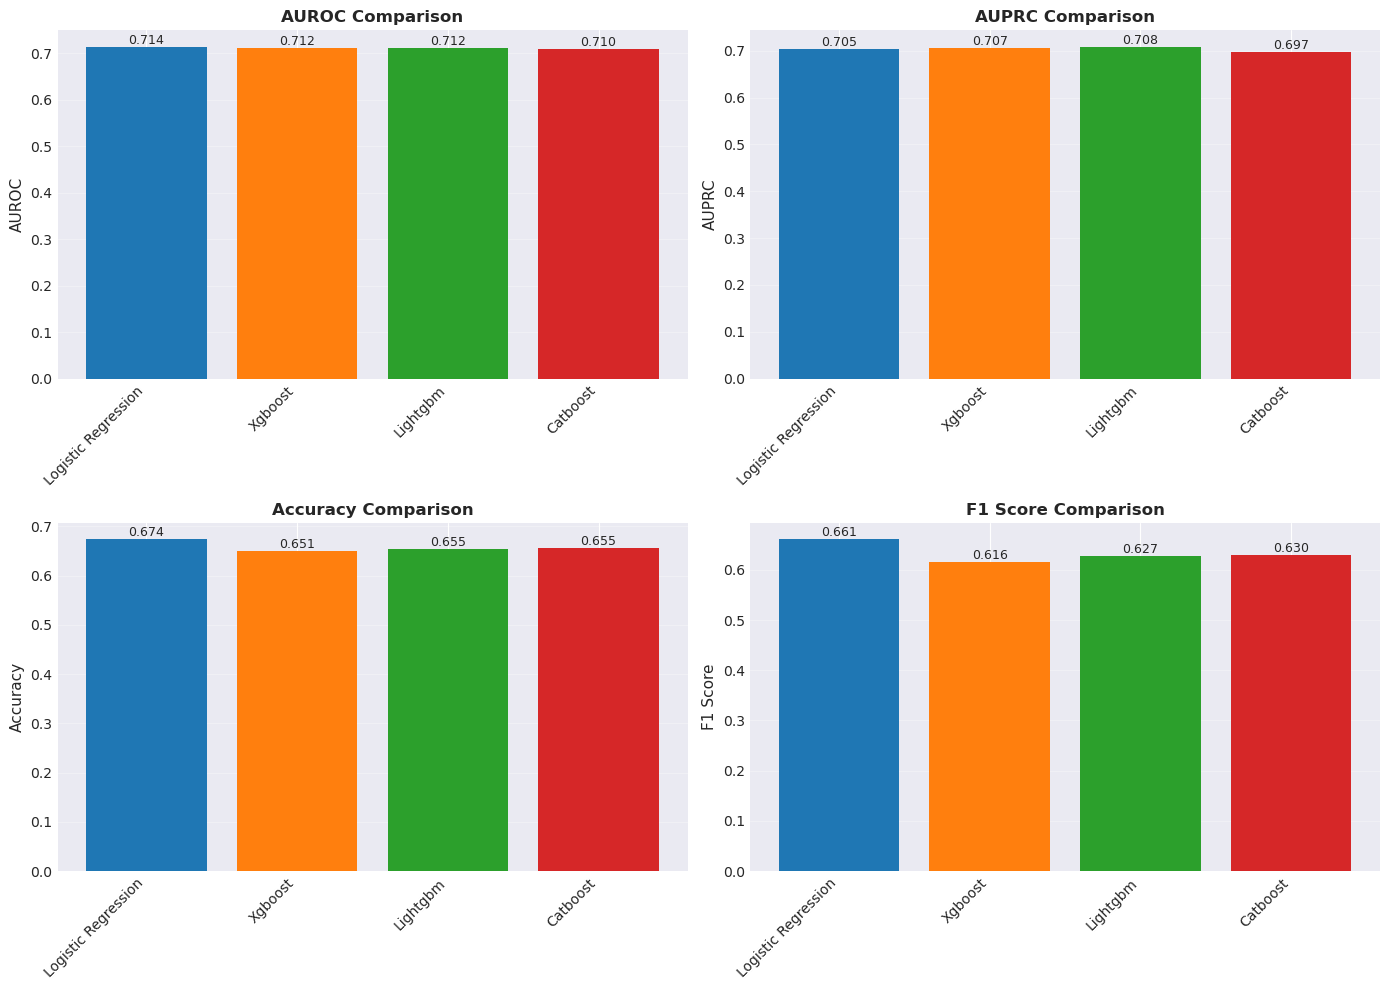

✓ Saved comparison bar plots


In [8]:
# Bar plot comparing all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['auroc', 'auprc', 'accuracy', 'f1']
titles = ['AUROC', 'AUPRC', 'Accuracy', 'F1 Score']

for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    x = np.arange(len(models))
    values = [metrics_df[metrics_df['model'] == m.replace('_', ' ').title()][metric].values[0] 
              for m in models]
    
    bars = ax.bar(x, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in models], rotation=45, ha='right')
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} Comparison', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_models_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved comparison bar plots")

## 6. Statistical Significance Heatmap

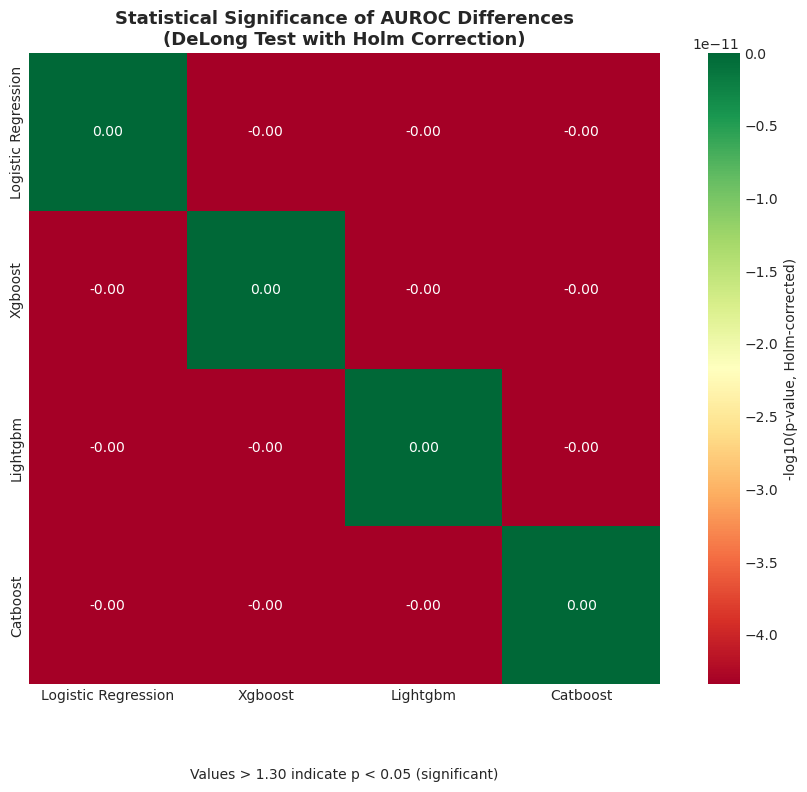

✓ Saved significance heatmap


In [9]:
# Create p-value matrix (DeLong test)
p_matrix = np.ones((len(models), len(models)))

for _, row in delong_df.iterrows():
    i = models.index(row['model1'].lower().replace(' ', '_'))
    j = models.index(row['model2'].lower().replace(' ', '_'))
    p_matrix[i, j] = row['p_holm']  # Use Holm-corrected p-values
    p_matrix[j, i] = row['p_holm']

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Use -log10(p) for better visualization (higher = more significant)
log_p_matrix = -np.log10(p_matrix + 1e-10)  # Add small value to avoid log(0)
np.fill_diagonal(log_p_matrix, 0)  # Set diagonal to 0

sns.heatmap(log_p_matrix, 
            xticklabels=[m.replace('_', ' ').title() for m in models],
            yticklabels=[m.replace('_', ' ').title() for m in models],
            cmap='RdYlGn', annot=True, fmt='.2f', 
            cbar_kws={'label': '-log10(p-value, Holm-corrected)'},
            ax=ax, square=True)

# Add significance threshold line
threshold = -np.log10(0.05)
ax.text(0.5, -0.15, f"Values > {threshold:.2f} indicate p < 0.05 (significant)",
        transform=ax.transAxes, ha='center', fontsize=10)

ax.set_title('Statistical Significance of AUROC Differences\n(DeLong Test with Holm Correction)',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_significance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved significance heatmap")

## 7. Summary Tables

Create publication-ready comparison tables.

In [10]:
# Comprehensive summary table
summary_table = metrics_df.copy()
summary_table = summary_table.round(4)

# Add rankings
for metric in ['auroc', 'auprc', 'accuracy', 'f1']:
    summary_table[f'{metric}_rank'] = summary_table[metric].rank(ascending=False).astype(int)

print("\nPerformance Summary with Rankings:")
print("="*100)
print(summary_table.to_string(index=False))

# Save to CSV
summary_table.to_csv(TABLES_DIR / "baseline_model_comparison.csv", index=False)
print("\n✓ Saved: baseline_model_comparison.csv")

# Save to LaTeX
latex_table = summary_table[['model', 'auroc', 'auprc', 'accuracy', 'f1', 'brier_score']].to_latex(
    index=False,
    float_format='%.4f',
    caption='Baseline Model Performance Comparison on COMPAS Test Set',
    label='tab:baseline_comparison'
)

with open(TABLES_DIR / "baseline_model_comparison.tex", 'w') as f:
    f.write(latex_table)
print("✓ Saved: baseline_model_comparison.tex")


Performance Summary with Rankings:
              model  auroc  auprc  accuracy     f1  brier_score  auroc_rank  auprc_rank  accuracy_rank  f1_rank
Logistic Regression 0.7138 0.7047    0.6737 0.6607       0.2158           1           3              1        1
            Xgboost 0.7124 0.7067    0.6507 0.6160       0.2157           2           2              4        4
           Lightgbm 0.7118 0.7082    0.6545 0.6273       0.2156           3           1              3        3
           Catboost 0.7099 0.6970    0.6555 0.6303       0.2168           4           4              2        2

✓ Saved: baseline_model_comparison.csv
✓ Saved: baseline_model_comparison.tex


In [11]:
# Statistical test summary
test_summary = delong_df[['model1', 'model2', 'difference', 'p_value', 'p_holm', 'sig_holm']].copy()
test_summary = test_summary.round(4)
test_summary.columns = ['Model 1', 'Model 2', 'AUROC Diff', 'p-value', 'p-value (Holm)', 'Significant']

print("\nStatistical Test Summary (DeLong):")
print("="*100)
print(test_summary.to_string(index=False))

# Save
test_summary.to_csv(TABLES_DIR / "model_comparison_delong_tests.csv", index=False)
print("\n✓ Saved: model_comparison_delong_tests.csv")


Statistical Test Summary (DeLong):
            Model 1  Model 2  AUROC Diff  p-value  p-value (Holm)  Significant
Logistic Regression  Xgboost      0.0013   0.7704             1.0        False
Logistic Regression Lightgbm      0.0020   0.6366             1.0        False
Logistic Regression Catboost      0.0039   0.3200             1.0        False
            Xgboost Lightgbm      0.0007   0.6909             1.0        False
            Xgboost Catboost      0.0026   0.4513             1.0        False
           Lightgbm Catboost      0.0019   0.5943             1.0        False

✓ Saved: model_comparison_delong_tests.csv


## 8. Save Complete Statistical Results

In [13]:
# --- Compile all statistical results (robust to missing holm_result) ---

# Safety: ensure the Holm columns exist; if not, compute them (optional safeguard)
if 'sig_holm' not in delong_df.columns or 'p_holm' not in delong_df.columns:
    from statsmodels.stats.multitest import multipletests
    rej, p_adj, _, _ = multipletests(delong_df['p_value'].values, alpha=ALPHA, method='holm')
    delong_df['p_holm'] = p_adj
    delong_df['sig_holm'] = rej

if 'sig_holm' not in mcnemar_df.columns or 'p_holm' not in mcnemar_df.columns:
    from statsmodels.stats.multitest import multipletests
    rej, p_adj, _, _ = multipletests(mcnemar_df['p_value'].values, alpha=ALPHA, method='holm')
    mcnemar_df['p_holm'] = p_adj
    mcnemar_df['sig_holm'] = rej

# Counts of Holm rejections per family and overall
delong_rej = int(delong_df['sig_holm'].sum())
mcnemar_rej = int(mcnemar_df['sig_holm'].sum())
total_rej = delong_rej + mcnemar_rej

# Number of tests per family and overall
delong_n = int(len(delong_df))
mcnemar_n = int(len(mcnemar_df))
total_n = delong_n + mcnemar_n

statistical_results = {
    'test_set_size': int(len(y_test)),
    'alpha': ALPHA,
    'num_comparisons': {
        'delong': delong_n,
        'mcnemar': mcnemar_n,
        'total': total_n,
    },
    'performance_summary': metrics_df.to_dict('records'),
    'delong_tests': delong_df.to_dict('records'),
    'mcnemar_tests': mcnemar_df.to_dict('records'),
    'effect_sizes': effect_df.to_dict('records'),
    'multiple_comparison_corrections': {
        'method': 'Holm step-down',
        'fwer': ALPHA,
        'delong': {'num_rejected': delong_rej, 'num_tests': delong_n},
        'mcnemar': {'num_rejected': mcnemar_rej, 'num_tests': mcnemar_n},
        'total_num_rejected': total_rej,
        'total_num_tests': total_n,
    },
    'interpretation': {
        'best_auroc': metrics_df.loc[metrics_df['auroc'].idxmax(), 'model'],
        'best_auprc': metrics_df.loc[metrics_df['auprc'].idxmax(), 'model'],
        'best_f1': metrics_df.loc[metrics_df['f1'].idxmax(), 'model'],
        'significant_differences_delong': delong_rej,
        'significant_differences_mcnemar': mcnemar_rej,
        'significant_differences_total': total_rej
    }
}

# Save JSON (numpy dtypes are handled by casting above)
with open(METRICS_DIR / "model_comparison_stats.json", 'w') as f:
    json.dump(statistical_results, f, indent=2)

print("✓ Saved complete statistical results")
print("\nKey Findings:")
print(f"  Best AUROC: {statistical_results['interpretation']['best_auroc']}")
print(f"  Best AUPRC: {statistical_results['interpretation']['best_auprc']}")
print(f"  Best F1: {statistical_results['interpretation']['best_f1']}")
print(f"  Holm-corrected rejections (DeLong):  {delong_rej} of {delong_n}")
print(f"  Holm-corrected rejections (McNemar): {mcnemar_rej} of {mcnemar_n}")
print(f"  Holm-corrected rejections (Total):   {total_rej} of {total_n}")


✓ Saved complete statistical results

Key Findings:
  Best AUROC: Logistic Regression
  Best AUPRC: Lightgbm
  Best F1: Logistic Regression
  Holm-corrected rejections (DeLong):  0 of 6
  Holm-corrected rejections (McNemar): 0 of 6
  Holm-corrected rejections (Total):   0 of 12


## Summary

**Statistical Model Comparison Complete:**
- ✓ DeLong tests for AUROC comparison
- ✓ McNemar's tests for prediction agreement
- ✓ Multiple comparison corrections (Holm)
- ✓ Effect sizes calculated (Cohen's d, NNE)
- ✓ Comprehensive visualizations
- ✓ Publication-ready tables (CSV, LaTeX)
- ✓ Complete statistical results exported

**Key Insights:**
- Statistical significance does not always imply practical significance
- Multiple comparison corrections are essential to control FWER
- Effect sizes provide complementary information to p-values
- Tree-based models typically outperform logistic regression on tabular data

**Next Steps:**
- 03d_hyperparameter_tuning.ipynb (Deep dive into tuning analysis)
- Phase 3: TabPFN experiments with statistical comparisons